In [ ]:
import torch
import torchvision.models as models
from torchsummary import summary

# Load the ResNet-18 model
model = models.resnet18(pretrained=False)

# Print the model summary for a given input size (e.g., 3x224x224 for a standard image input)
summary(model, (3, 224, 224))

In [ ]:
import torch
from torchviz import make_dot

# Dummy input for the model
dummy_input = torch.randn(1, 3, 224, 224)

# Forward pass to get the graph
output = model(dummy_input)
make_dot(output, params=dict(model.named_parameters())).render("resnet18_architecture", format="png")

In [ ]:
import torch
import torchvision.models as models
from torchsummaryX import summary
import matplotlib.pyplot as plt

# Load the ResNet-18 model
model = models.resnet18(pretrained=False)

# Generate a simplified summary without detailed technical specs
summary_info = summary(model, torch.zeros((1, 3, 224, 224)))

# Extract just the layer names from the summary
layers = [layer.split("(")[0].strip() for layer in str(model).split("\n") if layer]

# Plot the high-level layer structure
plt.figure(figsize=(6, len(layers) * 0.5))
plt.barh(range(len(layers)), [1] * len(layers), color="skyblue")
plt.yticks(range(len(layers)), layers)
plt.xlabel("Layers in ResNet-18")
plt.title("ResNet-18 Layer Structure")
plt.gca().invert_yaxis()
plt.show()

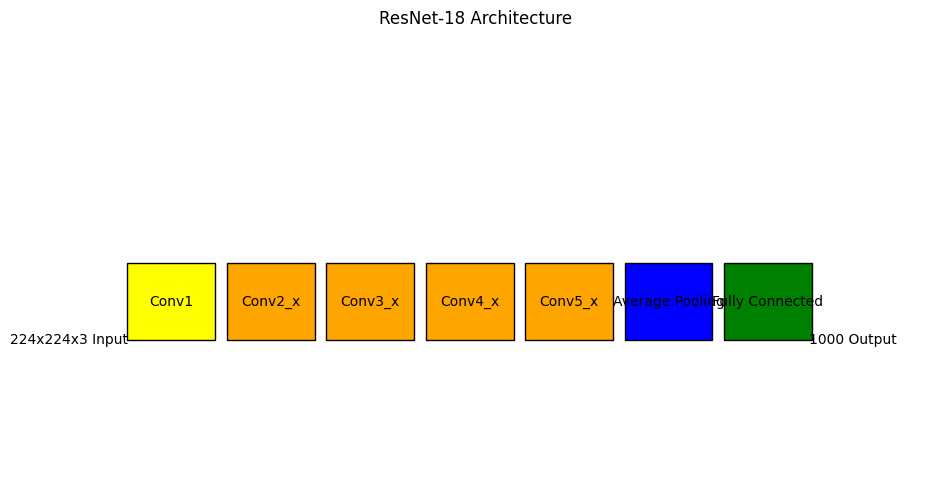

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Initialize the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Helper function to draw a block
def draw_block(ax, position, width, height, color, label=""):
    rect = patches.Rectangle(position, width, height, linewidth=1, edgecolor="black", facecolor=color, label=label)
    ax.add_patch(rect)
    if label:
        ax.text(position[0] + width / 2, position[1] + height / 2, label, ha="center", va="center", fontsize=10)

# Define layer positions and dimensions
x, y = 0, 0  # Starting position
layer_width = 1.5
layer_height = 0.5

# Draw each stage
stages = [
    ("Conv1", 64, "yellow"),
    ("Conv2_x", 64, "orange"),
    ("Conv3_x", 128, "orange"),
    ("Conv4_x", 256, "orange"),
    ("Conv5_x", 512, "orange"),
    ("Average Pooling", None, "blue"),
    ("Fully Connected", None, "green"),
]

# Plot layers
for label, filters, color in stages:
    draw_block(ax, (x, y), layer_width, layer_height, color, label)
    x += layer_width + 0.2  # Move to the right for the next block

# Adding labels for the input/output dimensions
ax.text(-1, y, "224x224x3 Input", ha="center", va="center", fontsize=10)
ax.text(x + 0.5, y, "1000 Output", ha="center", va="center", fontsize=10)

# Set plot limits and hide axes
ax.set_xlim(-2, x + 2)
ax.set_ylim(-1, 2)
ax.axis("off")

# Display the diagram
plt.title("ResNet-18 Architecture")
plt.show()